# Dynamic Interaction Multiorbital Results
This notebook visualizes the results generated by `dynamic_int_multiorb.py` and saved in `dynamic_int_multiorb.out.h5`.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from triqs.plot.mpl_interface import oplot
from h5 import HDFArchive
from triqs.operators import util
from triqs.gf import *

# Configure matplotlib for better quality plots
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.dpi'] = 100

### Load Data
Read the Green's functions, dynamic density-density correlations, and static observables from the HDF5 archive.

In [7]:
data_loc = "/home/andrewhardy/Documents/Data/CTHYB_Data"
ctseg_file = f"{data_loc}/ctseg_dynamic_int_multiorb.out.h5"
cthyb_file = f"{data_loc}/cthyb_dynamic_int_multiorb.out.h5"

with HDFArchive(ctseg_file, 'r') as ar:
    G_tau_seg = ar['G_tau']
    nn_tau_seg = ar['nn_tau']
    nn_seg = ar['nn']
    dens_seg = ar['densities']

with HDFArchive(cthyb_file, 'r') as ar:
    G_tau_hyb = ar['G_tau']
    O_tau_hyb = ar['O_tau']

print("CTSEG Static Densities:")
for k, v in dens_seg.items():
    print(f"  {k}: {v}")

print("\nCTSEG Static Density-Density correlations (nn):")
print(nn_seg)

CTSEG Static Densities:
  down_0: [0.16798032]
  down_1: [0.16832259]
  down_2: [0.16778956]
  up_0: [0.16787239]
  up_1: [0.16820172]
  up_2: [0.16771642]

CTSEG Static Density-Density correlations (nn):
{"('down_0', 'down_0')": array([[0.16798032]]), "('down_0', 'down_1')": array([[0.01353988]]), "('down_0', 'down_2')": array([[0.01350683]]), "('down_0', 'up_0')": array([[0.00511572]]), "('down_0', 'up_1')": array([[0.0095133]]), "('down_0', 'up_2')": array([[0.00950212]]), "('down_1', 'down_0')": array([[0.01353988]]), "('down_1', 'down_1')": array([[0.16832259]]), "('down_1', 'down_2')": array([[0.01351027]]), "('down_1', 'up_0')": array([[0.00951201]]), "('down_1', 'up_1')": array([[0.00512439]]), "('down_1', 'up_2')": array([[0.0095092]]), "('down_2', 'down_0')": array([[0.01350683]]), "('down_2', 'down_1')": array([[0.01351027]]), "('down_2', 'down_2')": array([[0.16778956]]), "('down_2', 'up_0')": array([[0.00949629]]), "('down_2', 'up_1')": array([[0.00950288]]), "('down_2', '

### Green's Function $G(\tau)$

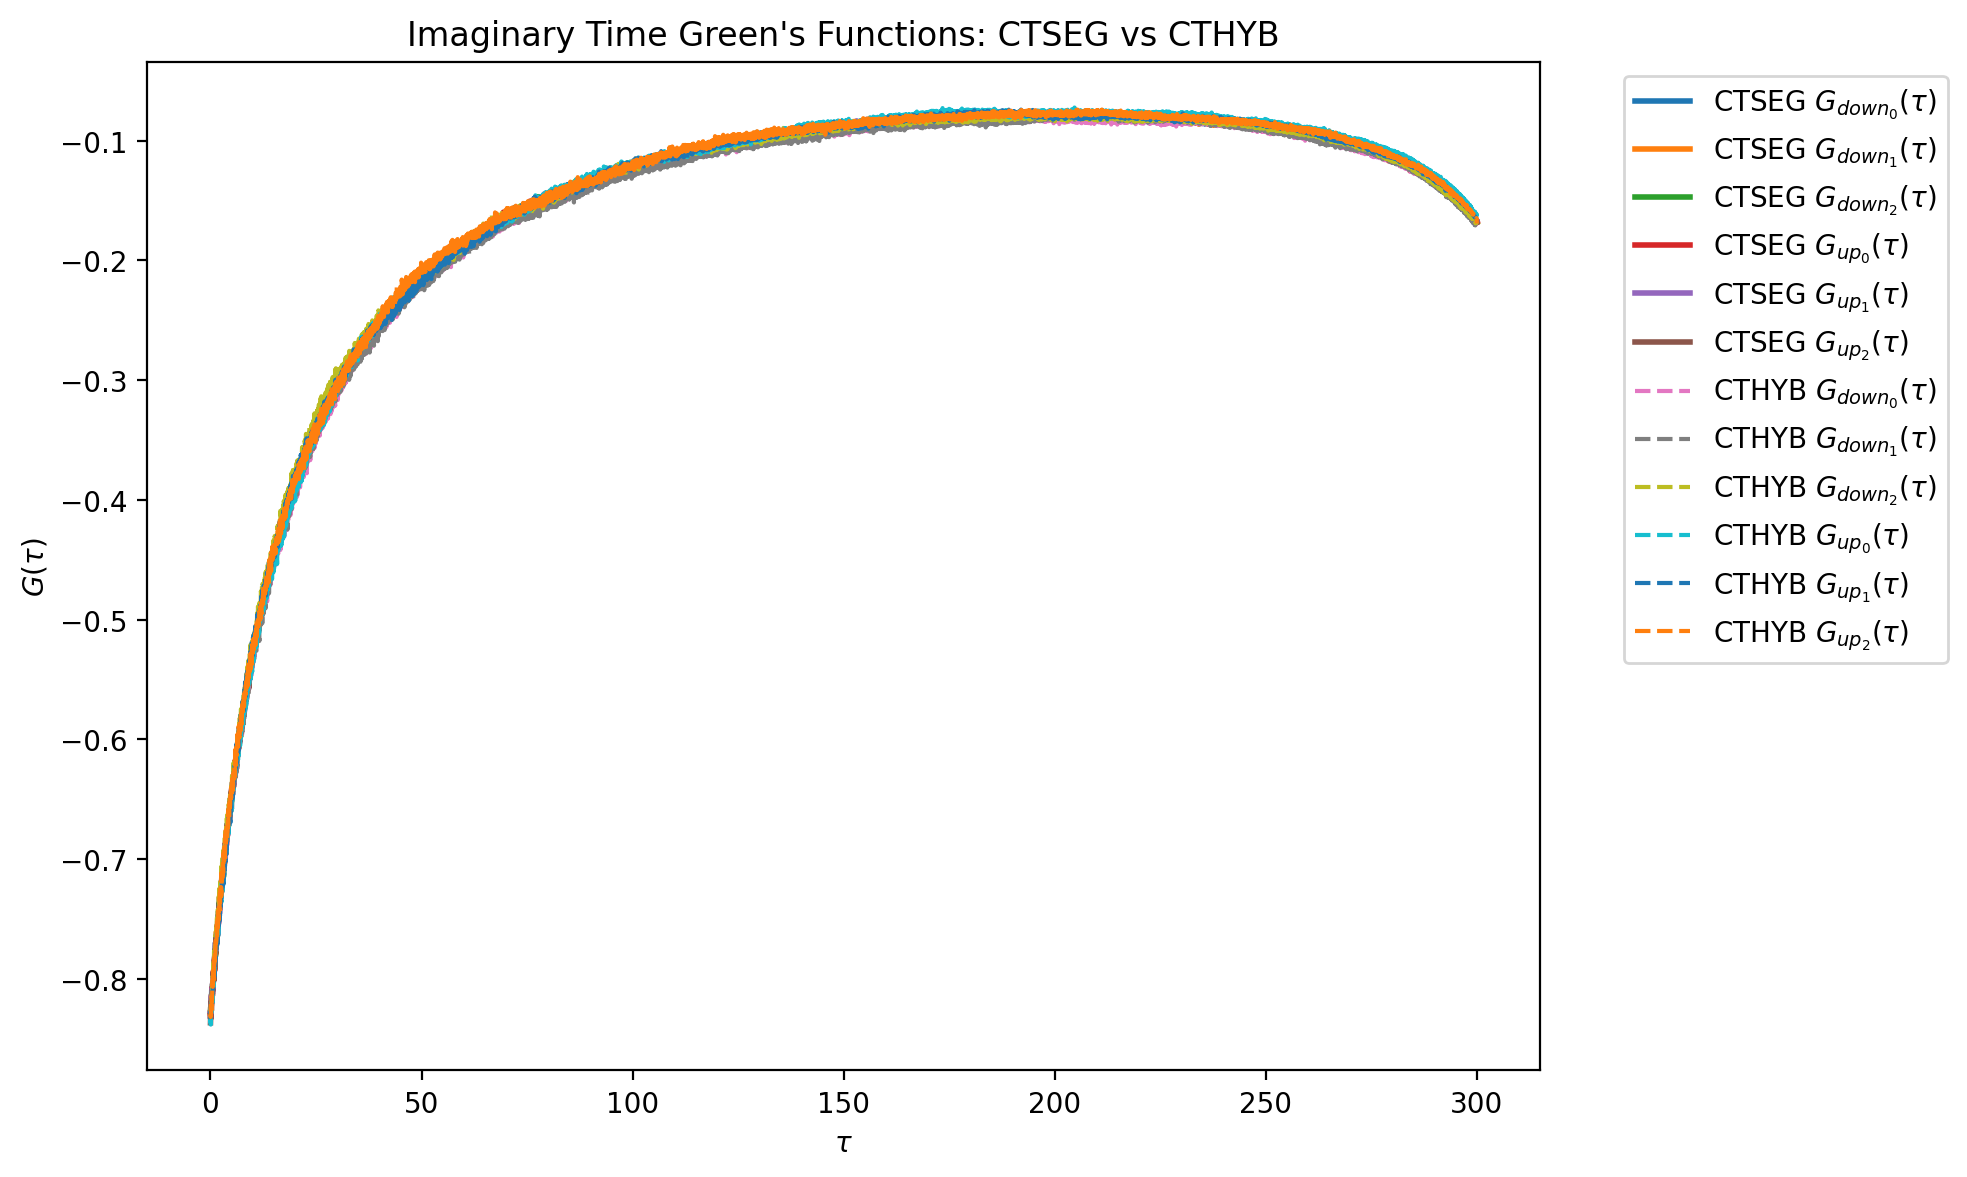

In [9]:
plt.figure(figsize=(10, 6))

for name, block in G_tau_seg:
    oplot(block.real, label=rf"CTSEG $G_{{{name}}}(\tau)$", linewidth=2.0)

for name, block in G_tau_hyb:
    oplot(block.real, '--', label=rf"CTHYB $G_{{{name}}}(\tau)$", linewidth=1.5)

plt.title("Imaginary Time Green's Functions: CTSEG vs CTHYB")
plt.ylabel(r"$G(\tau)$")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Dynamic Density-Density Correlations $nn(\tau)$

In [ ]:
nn_tau_seg

Green's Function nn_tau composed of 36 2-index blocks: 
 Green's Function nn_tau_('down_0', 'down_0') with mesh Imaginary time mesh with beta = 300, statistics = Boson, N = 10001 and target_shape (1, 1): 
 
 Green's Function nn_tau_('down_0', 'down_1') with mesh Imaginary time mesh with beta = 300, statistics = Boson, N = 10001 and target_shape (1, 1): 
 
 Green's Function nn_tau_('down_0', 'down_2') with mesh Imaginary time mesh with beta = 300, statistics = Boson, N = 10001 and target_shape (1, 1): 
 
 Green's Function nn_tau_('down_0', 'up_0') with mesh Imaginary time mesh with beta = 300, statistics = Boson, N = 10001 and target_shape (1, 1): 
 
 Green's Function nn_tau_('down_0', 'up_1') with mesh Imaginary time mesh with beta = 300, statistics = Boson, N = 10001 and target_shape (1, 1): 
 
 Green's Function nn_tau_('down_0', 'up_2') with mesh Imaginary time mesh with beta = 300, statistics = Boson, N = 10001 and target_shape (1, 1): 
 
 Green's Function nn_tau_('down_1', 'down_0'

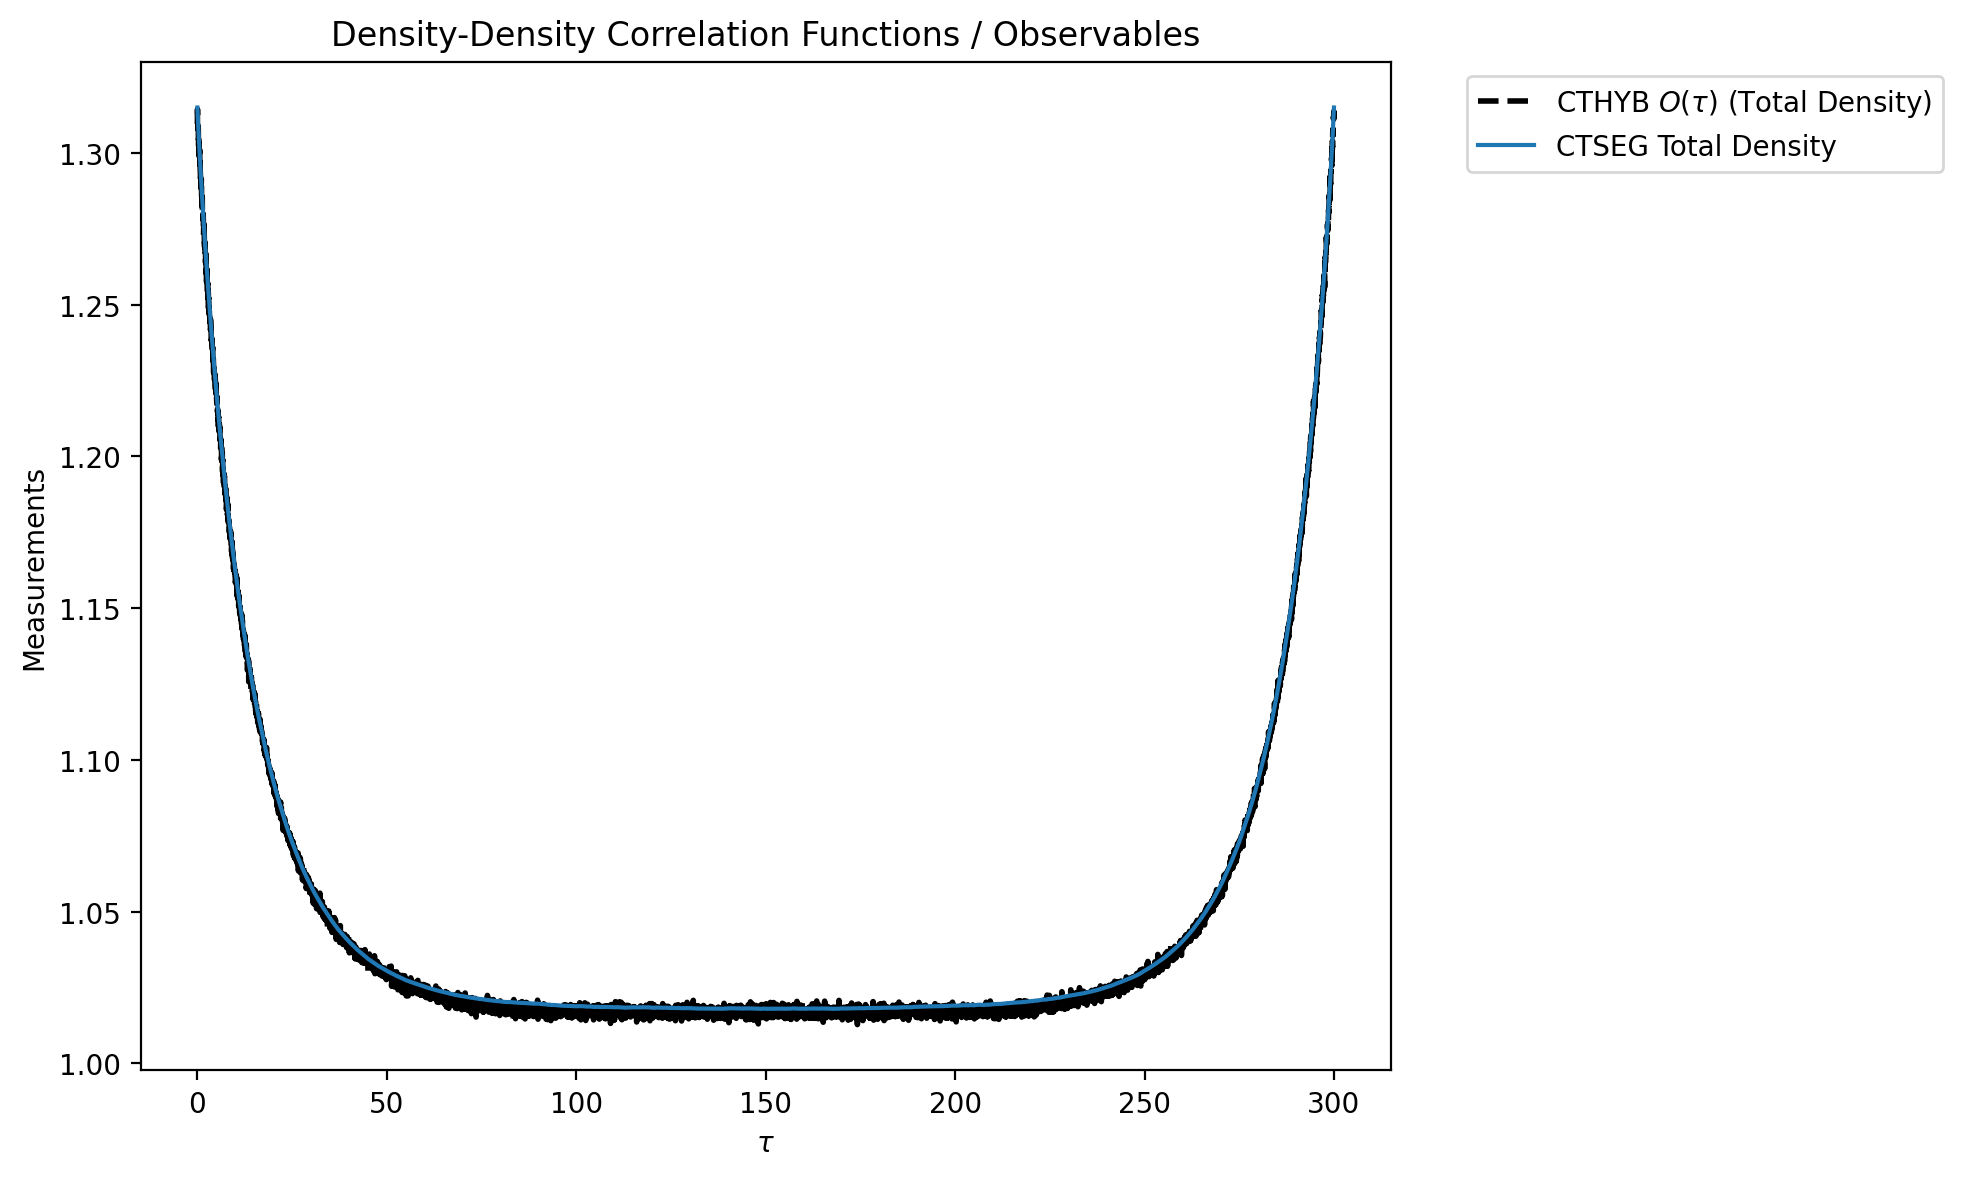

In [16]:
plt.figure(figsize=(10, 6))

# Initialize with the first block
N_tot_seg = None

for name, block in nn_tau_seg:
    if N_tot_seg is None:
        N_tot_seg = block.copy()
    else:
        N_tot_seg += block

# Now you can plot it alongside the CTHYB result
oplot(O_tau_hyb.real, '--', label="CTHYB $O(\\tau)$ (Total Density)", linewidth=2.0, color='black')
oplot(N_tot_seg.real, label="CTSEG Total Density", linewidth=1.5)

plt.title("Density-Density Correlation Functions / Observables")
plt.ylabel(r"Measurements")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()